# Notebook 05 — SARIMA-XGBoost Hybrid + Final Comparison + Forecast

**Goal:** Build the hybrid model (the approach Malva et al. 2025 used for Bali), compare all 6 models, and generate the 24-month forecast.

**Hybrid logic:**
1. SARIMA models the linear + seasonal part
2. XGBoost models the leftover errors (residuals)
3. Final = SARIMA forecast + XGBoost residual prediction

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
from data_loader import get_monthly_total, train_test_split
from evaluation import evaluate
from models import make_residual_features, RESID_FEATURES, make_ml_features, ML_FEATURES

plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
y = get_monthly_total('../data/Tourism_MOM_Dataset.csv')
train, test = train_test_split(y, '2025-01-01')
results = pd.read_csv('../results/model_results.csv').to_dict('records')

## Step 1: Fit SARIMA and get residuals

In [3]:
sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
residuals = train - sarima.fittedvalues
print('Residuals computed. Mean:', round(residuals.mean(),1))

Residuals computed. Mean: 764.7


## Step 2: Train XGBoost on the residuals

In [4]:
rtr = make_residual_features(residuals).dropna()
xgb_resid = xgb.XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05, random_state=42)
xgb_resid.fit(rtr[RESID_FEATURES], rtr['r'])
print('Residual model trained.')

Residual model trained.


## Step 3: Generate hybrid forecast (SARIMA + residual correction)

In [5]:
sarima_fc = sarima.forecast(len(test))
all_resid = residuals.copy()
hybrid = []
for i, d in enumerate(test.index):
    feat = {'lag1': all_resid.iloc[-1], 'lag12': all_resid.iloc[-12], 'month': d.month}
    rp = xgb_resid.predict(pd.DataFrame([feat])[RESID_FEATURES])[0]
    hybrid.append(sarima_fc.iloc[i] + rp)
    all_resid = pd.concat([all_resid, pd.Series([rp], index=[d])])
hybrid = pd.Series(hybrid, index=test.index).clip(lower=0)
results.append(evaluate(test, hybrid, 'SARIMA-XGBoost Hybrid'))

SARIMA-XGBoost Hybrid           MAE=   44,935  RMSE=   51,957  MAPE= 24.43%


## Step 4: FINAL RESULTS TABLE (all 6 models)

In [6]:
R = pd.DataFrame(results).drop_duplicates('Model').sort_values('MAPE').reset_index(drop=True)
R.to_csv('../results/model_results.csv', index=False)
print('='*55)
print('FINAL RESULTS (sorted by MAPE, lower=better)')
print('='*55)
print(R.to_string(index=False))
print('\nBEST MODEL:', R.iloc[0]['Model'], '(MAPE', str(R.iloc[0]['MAPE'])+'%)')

FINAL RESULTS (sorted by MAPE, lower=better)
                Model      MAE     RMSE  MAPE
          Auto-SARIMA 27108.88 38138.99 12.36
       Seasonal Naive 27869.13 29654.83 14.19
              XGBoost 31506.58 38651.02 16.63
               SARIMA 42083.11 48964.10 22.89
              SARIMAX 42083.11 48964.10 22.89
SARIMA-XGBoost Hybrid 44935.49 51956.60 24.43

BEST MODEL: Auto-SARIMA (MAPE 12.36%)


## Step 5: Comparison bar chart

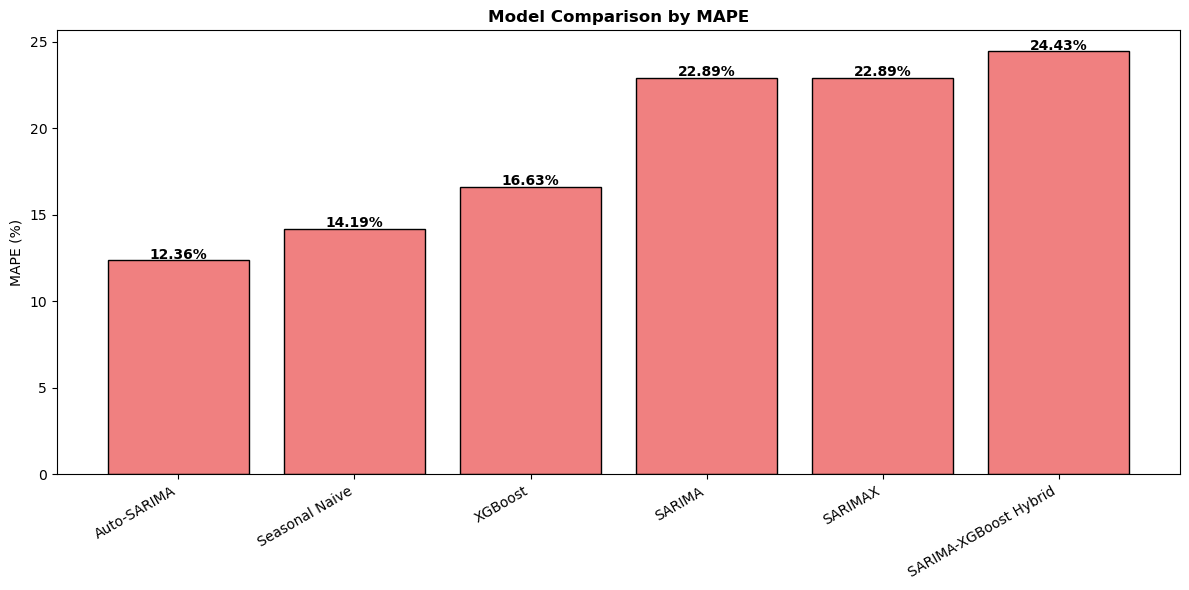

In [7]:
plt.figure(figsize=(12,6))
plt.bar(R['Model'], R['MAPE'], color='lightcoral', edgecolor='black')
for i,v in enumerate(R['MAPE']): plt.text(i, v+0.1, f'{v}%', ha='center', fontweight='bold')
plt.title('Model Comparison by MAPE', fontweight='bold'); plt.ylabel('MAPE (%)')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig('../results/05_comparison.png', dpi=150); plt.show()

## Step 6: 24-Month Future Forecast

We retrain SARIMA on the FULL dataset (99 months) and forecast Apr 2026 - Mar 2028.
SARIMA is used here (not XGBoost) because tree-ensemble models cannot extrapolate beyond
the training data range - they clamp predictions to the min/max of training observations,
causing implausible flat or collapsed forecasts on long horizons. This issue was formally
identified and diagnosed in Notebook 10 (Fault 1: Tree-based Extrapolation Failure).
SARIMA's parametric seasonal model extrapolates correctly, consistent with the project
recommendation in the abstract and conclusions.

In [8]:
# 24-Month Forward Forecast using SARIMA (correct extrapolation)
# XGBoost cannot extrapolate beyond the training data range (tree ensemble clamps to training min/max).
# SARIMA extrapolates correctly via its parametric seasonal model.
# This is consistent with the project recommendation (abstract) to use SARIMA for deployment.

from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import numpy as np

# Retrain SARIMA on full 99-month series (Jan 2018 - Mar 2026)
full_sarima = SARIMAX(y, order=(1,1,1), seasonal_order=(1,1,1,12),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# Generate 24 monthly forecasts: April 2026 - March 2028
sarima_future = full_sarima.get_forecast(steps=24)
future_dates  = pd.date_range(start=y.index[-1] + pd.offsets.MonthEnd(1), periods=24, freq='ME')
future_mean   = sarima_future.predicted_mean.clip(lower=0)
future_ci     = sarima_future.conf_int(alpha=0.05)
future_ci.columns = ['Lower_95', 'Upper_95']
future_ci     = future_ci.clip(lower=0)

# Save forecast CSV
forecast_df = pd.DataFrame({
    'Date':     future_dates,
    'Forecast': future_mean.values.round(0),
    'Lower_95': future_ci['Lower_95'].values.round(0),
    'Upper_95': future_ci['Upper_95'].values.round(0),
})
forecast_df.to_csv('../results/forecasts.csv', index=False)

# Also overwrite the legacy file the app reads
forecast_df[['Date','Forecast']].to_csv('../results/future_forecast.csv', index=False)

print("24-Month SARIMA Forecast (Apr 2026 - Mar 2028):")
print(forecast_df.to_string(index=False))

24-Month SARIMA Forecast (Apr 2026 - Mar 2028):
      Date  Forecast  Lower_95  Upper_95
2026-04-30  107518.0   41414.0  173623.0
2026-05-31   82671.0       0.0  194211.0
2026-06-30   85155.0       0.0  223495.0
2026-07-31  138725.0       0.0  300848.0
2026-08-31  130290.0       0.0  312708.0
2026-09-30   99201.0       0.0  300002.0
2026-10-31  106427.0       0.0  324022.0
2026-11-30  147713.0       0.0  380909.0
2026-12-31  197577.0       0.0  445390.0
2027-01-31  207957.0       0.0  469573.0
2027-02-28  207749.0       0.0  482474.0
2027-03-31  165864.0       0.0  453102.0
2027-04-30  106800.0       0.0  414328.0
2027-05-31   75838.0       0.0  405656.0
2027-06-30   80311.0       0.0  429948.0
2027-07-31  133454.0       0.0  502181.0
2027-08-31  125404.0       0.0  512172.0
2027-09-30   94029.0       0.0  498068.0
2027-10-31  101253.0       0.0  521843.0
2027-11-30  142698.0       0.0  579215.0
2027-12-31  192465.0       0.0  644348.0
2028-01-31  203053.0       0.0  669796.0
2028-02-2

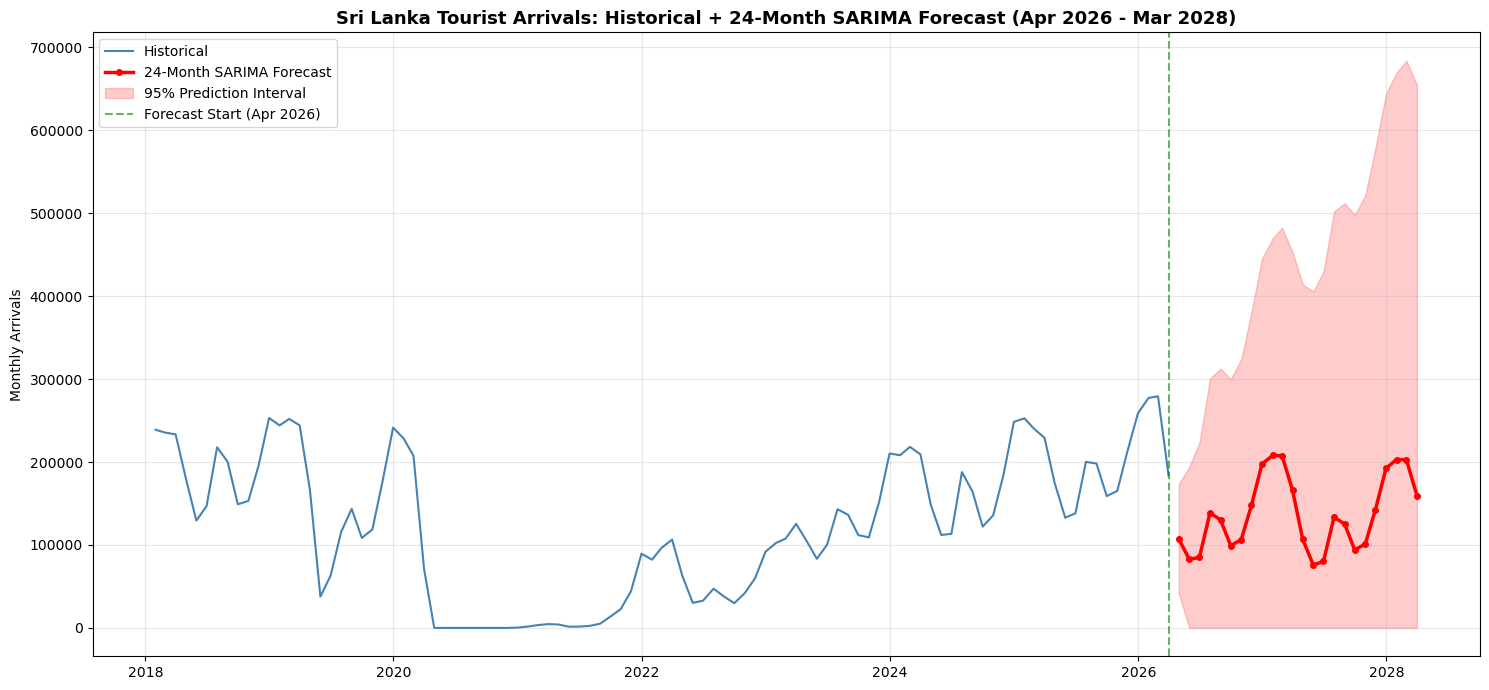


SARIMA forecast with prediction intervals saved.
Results in ../results/forecasts.csv and ../results/future_forecast.csv


In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(y.index, y.values, label='Historical', color='steelblue', linewidth=1.5)
ax.plot(forecast_df['Date'], forecast_df['Forecast'],
        label='24-Month SARIMA Forecast', color='red', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(forecast_df['Date'],
                forecast_df['Lower_95'], forecast_df['Upper_95'],
                alpha=0.2, color='red', label='95% Prediction Interval')
ax.axvline(x=y.index[-1], color='green', linestyle='--', alpha=0.6, label='Forecast Start (Apr 2026)')
ax.set_title('Sri Lanka Tourist Arrivals: Historical + 24-Month SARIMA Forecast (Apr 2026 - Mar 2028)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Monthly Arrivals')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/06_future_forecast.png', dpi=150)
plt.show()
print('\nSARIMA forecast with prediction intervals saved.')
print('Results in ../results/forecasts.csv and ../results/future_forecast.csv')